<a href="https://colab.research.google.com/github/tonywahome/linear_regression_model/blob/main/Anxiety_Predicting_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ANXIETY PREDICITNG APP

My mission is to increase access to mental health services across Africa through intergrating technological tools to help patients quickly self diagnose based on self reflection, helping them be aware of their mental state an wellbeing and subsequently reducing the costs of acceesing mental healthcare

I developed an anxiety prediciting application that leverages Random Forest regression Model to self diagnose patients based on factors such as history of mental health disorders, level of alcohol and drug use and mood.

The model analyses the revalence of mental health disorders, depression, alcohol and drug use and gives a percentage score of the anxiety level of the user.

This model aims to give a quick quantified score o anxiety based on factors that tend to be correlated to anxiety according to the [American Psychological Association](https://www.apa.org/education-career/training/psyclearn-anxiety-addictive-behaviors-series
)

## Import Required Libraries

In [123]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Load Datasets

In [124]:
suicide_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\suicide_rates_2019.csv')
mental_health_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\Mental health Depression disorder Data.csv')
anxiety_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\prevalence-of-anxiety-disorders-males-vs-females.csv')
bipolar_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\prevalence-of-bipolar-disorder-in-males-vs-females.csv')
eating_disorder_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\prevalence-of-eating-disorders-in-males-vs-females.csv')
schizophrenia_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\prevalence-of-schizophrenia-in-males-vs-females.csv')
road_deaths_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\road_death_2019.csv')
suicide_rate_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\suicide-rate-by-country-2023.csv')
worldHappiness_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\World Happiness Report 2005-2021.csv')
depression_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\prevalence-of-depression-males-vs-females.csv')



display(mental_health_df)
display(anxiety_df)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\1003434404.py:2: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  mental_health_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\linear_regression\mental_health_data\Mental health Depression disorder Data.csv')


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260
...,...,...,...,...,...,...,...,...,...,...,...
108548,108548,Zimbabwe,ZWE,2013,303564.60359,NaN,NaN,NaN,NaN,NaN,NaN
108549,108549,Zimbabwe,ZWE,2014,311665.769283,NaN,NaN,NaN,NaN,NaN,NaN
108550,108550,Zimbabwe,ZWE,2015,320638.507158,NaN,NaN,NaN,NaN,NaN,NaN
108551,108551,Zimbabwe,ZWE,2016,330437.353798,NaN,NaN,NaN,NaN,NaN,NaN


,index,Entity,Code,Year,Prevalence - Anxiety disorders - Sex: Male - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Female - Age: Age-standardized (Percent),Population (historical estimates),Continent
0,0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,Asia
1,1,Afghanistan,AFG,1990,3.556843,5.971172,12412311.0,NaN
2,2,Afghanistan,AFG,1991,3.548885,5.980482,13299016.0,NaN
3,3,Afghanistan,AFG,1992,3.542779,5.988175,14485543.0,NaN
4,4,Afghanistan,AFG,1993,3.538304,5.993858,15816601.0,NaN
...,...,...,...,...,...,...,...,...
56390,56390,Zimbabwe,ZWE,1988,NaN,NaN,9849129.0,NaN
56391,56391,Zimbabwe,ZWE,1989,NaN,NaN,10153852.0,NaN
56392,56392,Zimbabwe,ZWE,2020,NaN,NaN,14862927.0,NaN
56393,56393,Zimbabwe,ZWE,2021,NaN,NaN,15092171.0,NaN


## Merge Datasets  

In [125]:
# Ensure 'Year' columns are of the same type before merging
mental_health_df['Year'] = pd.to_numeric(mental_health_df['Year'], errors='coerce')
anxiety_df['Year'] = pd.to_numeric(anxiety_df['Year'], errors='coerce')

# Drop rows with NaN in 'Year' after conversion
mental_health_df = mental_health_df.dropna(subset=['Year'])
anxiety_df = anxiety_df.dropna(subset=['Year'])

# Convert 'Year' to int after dropping NaNs
mental_health_df['Year'] = mental_health_df['Year'].astype(int)
anxiety_df['Year'] = anxiety_df['Year'].astype(int)

# initialize master_df with mental_health_df and merge with anxiety_df
master_df = pd.merge(
	mental_health_df,
	anxiety_df,
	how='inner',
	left_on=['Entity', 'Year'],
	right_on=['Entity', 'Year']
)

# Display the merged DataFrame
display(master_df)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\2045933921.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mental_health_df['Year'] = mental_health_df['Year'].astype(int)


,index_x,Entity,Code_x,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%),index_y,Code_y,Prevalence - Anxiety disorders - Sex: Male - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Female - Age: Age-standardized (Percent),Population (historical estimates),Continent
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404,1,AFG,3.556843,5.971172,12412311.0,NaN
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768,2,AFG,3.548885,5.980482,13299016.0,NaN
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644,3,AFG,3.542779,5.988175,14485543.0,NaN
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738,4,AFG,3.538304,5.993858,15816601.0,NaN
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260,5,AFG,3.535309,5.997363,17075728.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103443,108548,Zimbabwe,ZWE,2013,303564.60359,NaN,NaN,NaN,NaN,NaN,NaN,56158,ZWE,3.044492,3.512828,13350378.0,NaN
103444,108549,Zimbabwe,ZWE,2014,311665.769283,NaN,NaN,NaN,NaN,NaN,NaN,56159,ZWE,3.045145,3.523853,13586710.0,NaN
103445,108550,Zimbabwe,ZWE,2015,320638.507158,NaN,NaN,NaN,NaN,NaN,NaN,56160,ZWE,3.047380,3.533207,13814642.0,Africa
103446,108551,Zimbabwe,ZWE,2016,330437.353798,NaN,NaN,NaN,NaN,NaN,NaN,56161,ZWE,3.045751,3.549726,14030338.0,NaN


## Further Data Cleaning

Filter nulls



In [126]:
mental_health_df = mental_health_df.dropna()
display(mental_health_df)


print(mental_health_df.info())

,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260
...,...,...,...,...,...,...,...,...,...,...,...
6463,6463,Zimbabwe,ZWE,2013,0.15567,0.607993,0.117248,3.090168,0.766280,3.128192,1.515641
6464,6464,Zimbabwe,ZWE,2014,0.155993,0.60861,0.118073,3.093964,0.768914,3.140290,1.515470
6465,6465,Zimbabwe,ZWE,2015,0.156465,0.609363,0.11947,3.098687,0.771802,3.155710,1.514751
6466,6466,Zimbabwe,ZWE,2016,0.157111,0.610234,0.121456,3.104294,0.772275,3.174134,1.513269


<class 'pandas.core.frame.DataFrame'>
Index: 5488 entries, 0 to 6467
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      5488 non-null   int64  
 1   Entity                     5488 non-null   object 
 2   Code                       5488 non-null   object 
 3   Year                       5488 non-null   int64  
 4   Schizophrenia (%)          5488 non-null   object 
 5   Bipolar disorder (%)       5488 non-null   object 
 6   Eating disorders (%)       5488 non-null   object 
 7   Anxiety disorders (%)      5488 non-null   float64
 8   Drug use disorders (%)     5488 non-null   float64
 9   Depression (%)             5488 non-null   float64
 10  Alcohol use disorders (%)  5488 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 514.5+ KB
None


Changing Datatypes for further analysis and linear regression 

In [127]:
# change schizophrenia(%), bipolar(%), Eating disorders (%) to float
mental_health_df['Schizophrenia (%)'] = mental_health_df['Schizophrenia (%)'].astype(float)
mental_health_df['Bipolar disorder (%)'] = mental_health_df['Bipolar disorder (%)'].astype(float)
mental_health_df['Eating disorders (%)'] = mental_health_df['Eating disorders (%)'].astype(float)

#convert year to int
mental_health_df['Year'] = mental_health_df['Year'].astype(int)
print(mental_health_df.info())
                                                

<class 'pandas.core.frame.DataFrame'>
Index: 5488 entries, 0 to 6467
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      5488 non-null   int64  
 1   Entity                     5488 non-null   object 
 2   Code                       5488 non-null   object 
 3   Year                       5488 non-null   int64  
 4   Schizophrenia (%)          5488 non-null   float64
 5   Bipolar disorder (%)       5488 non-null   float64
 6   Eating disorders (%)       5488 non-null   float64
 7   Anxiety disorders (%)      5488 non-null   float64
 8   Drug use disorders (%)     5488 non-null   float64
 9   Depression (%)             5488 non-null   float64
 10  Alcohol use disorders (%)  5488 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 514.5+ KB
None


In [128]:
display(mental_health_df)

,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.160560,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260
...,...,...,...,...,...,...,...,...,...,...,...
6463,6463,Zimbabwe,ZWE,2013,0.155670,0.607993,0.117248,3.090168,0.766280,3.128192,1.515641
6464,6464,Zimbabwe,ZWE,2014,0.155993,0.608610,0.118073,3.093964,0.768914,3.140290,1.515470
6465,6465,Zimbabwe,ZWE,2015,0.156465,0.609363,0.119470,3.098687,0.771802,3.155710,1.514751
6466,6466,Zimbabwe,ZWE,2016,0.157111,0.610234,0.121456,3.104294,0.772275,3.174134,1.513269


## Explolatory Data Analysis

Data Visualizations to investigate relationships

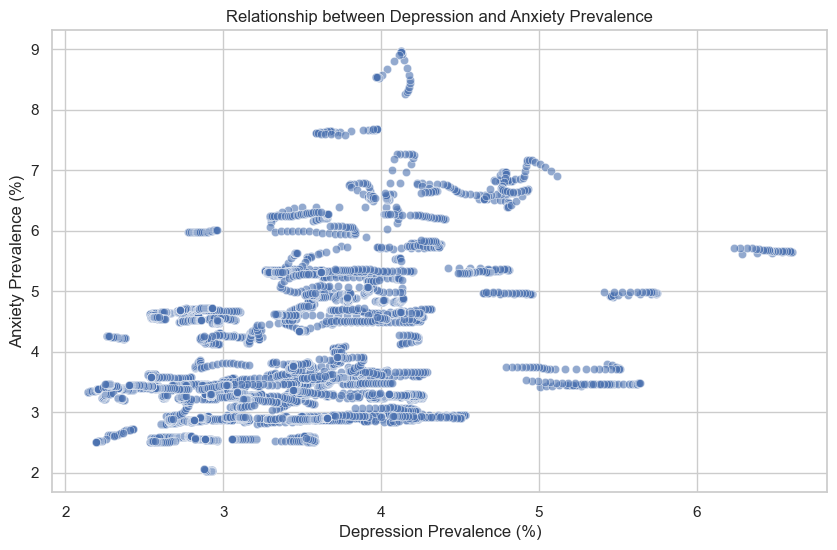

In [129]:
# scatter plot showing the relationship between depression and anxiety
plt.figure(figsize=(10, 6))
sns.scatterplot(data=mental_health_df, x='Depression (%)', y='Anxiety disorders (%)', alpha=0.6)
plt.title('Relationship between Depression and Anxiety Prevalence')
plt.xlabel('Depression Prevalence (%)')
plt.ylabel('Anxiety Prevalence (%)')
plt.grid(True)
plt.show()

# moderate positive correlation between the two variables. 
# This means that as the prevalence of depression (%) increases,
# the prevalence of anxiety (%) also tends to increase.
# clustering of data points, indicating that there are groups of countries with similar levels of depression and anxiety prevalence.
# comorbidity btn depression and anxiety

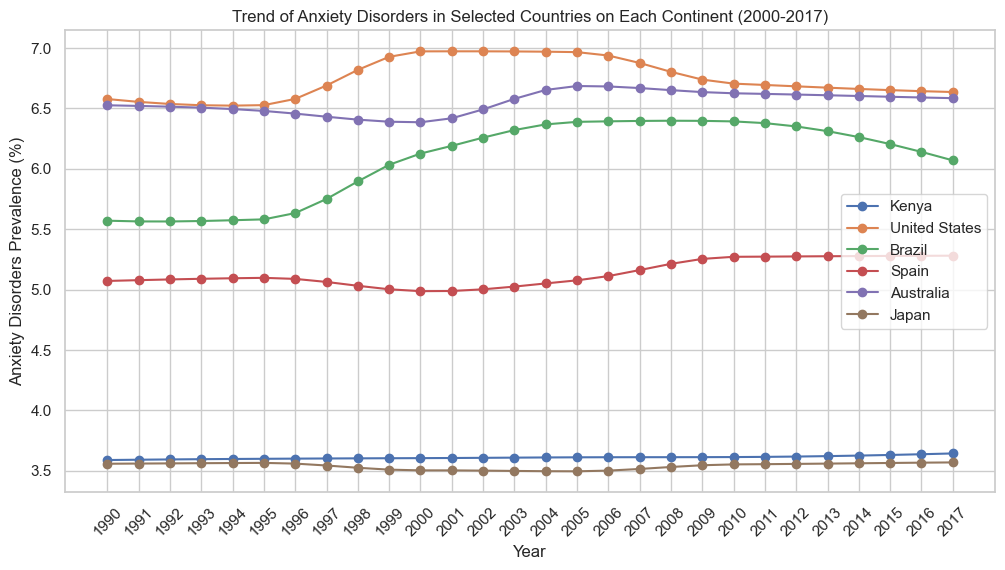

In [170]:
#line graph showing the trend of anxiety disorders in Kenya, USA, Brazil, Spain, Australia, and Japan over the years
plt.figure(figsize=(12, 6))
for country in ['Kenya', 'United States', 'Brazil', 'Spain', 'Australia', 'Japan']:
    country_data = mental_health_df[mental_health_df['Entity'] == country]
    plt.plot(country_data['Year'], country_data['Anxiety disorders (%)'], marker='o', label=country)    
plt.title('Trend of Anxiety Disorders in Selected Countries on Each Continent (2000-2017)')
plt.xlabel('Year')
plt.ylabel('Anxiety Disorders Prevalence (%)')
plt.xticks(country_data['Year'], rotation=45)
plt.legend()
plt.grid(True)
plt.show()


# trend of anxiety disorders in Kenya, USA, Brazil, Spain, Australia, and Japan over the years
# Higher prevalence in developed nations e.g. USA. 
#Low prevalence in Japan. Other factors such as social support, cultural attitudes can be in play



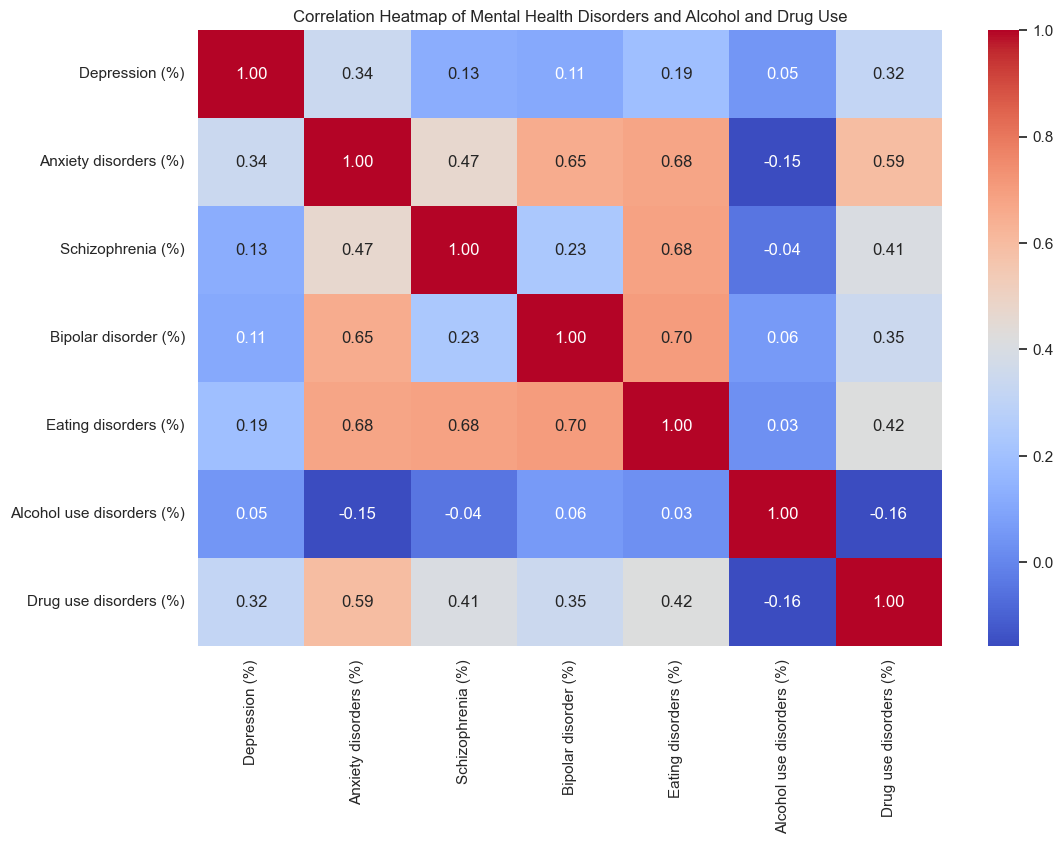

In [131]:

# heatmap showing the correlation between depression, anxiety, schizophrenia, bipolar, eating disorder and alcohol use and drug use disorders
plt.figure(figsize=(12, 8))
correlation_matrix = mental_health_df[['Depression (%)', 'Anxiety disorders (%)', 'Schizophrenia (%)', 'Bipolar disorder (%)', 'Eating disorders (%)', 'Alcohol use disorders (%)', 'Drug use disorders (%)']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Mental Health Disorders and Alcohol and Drug Use')
plt.show() 

# direct relationship between anxiety and other mental health disorders and Drug use
# little to no relationship between anxiety and alcohol use disorders

There are strong positive correlations among several mental health disorders, suggesting they often occur together. The strongest pairs are:

- Bipolar disorder and Eating disorders (r=0.70)

- Anxiety and Eating disorders (r=0.68)

- Schizophrenia and Eating disorders (r=0.68)

- Anxiety and Bipolar disorder (r=0.65)

To investigate further it is rational to create interaction terms to visualize much more complex relationships


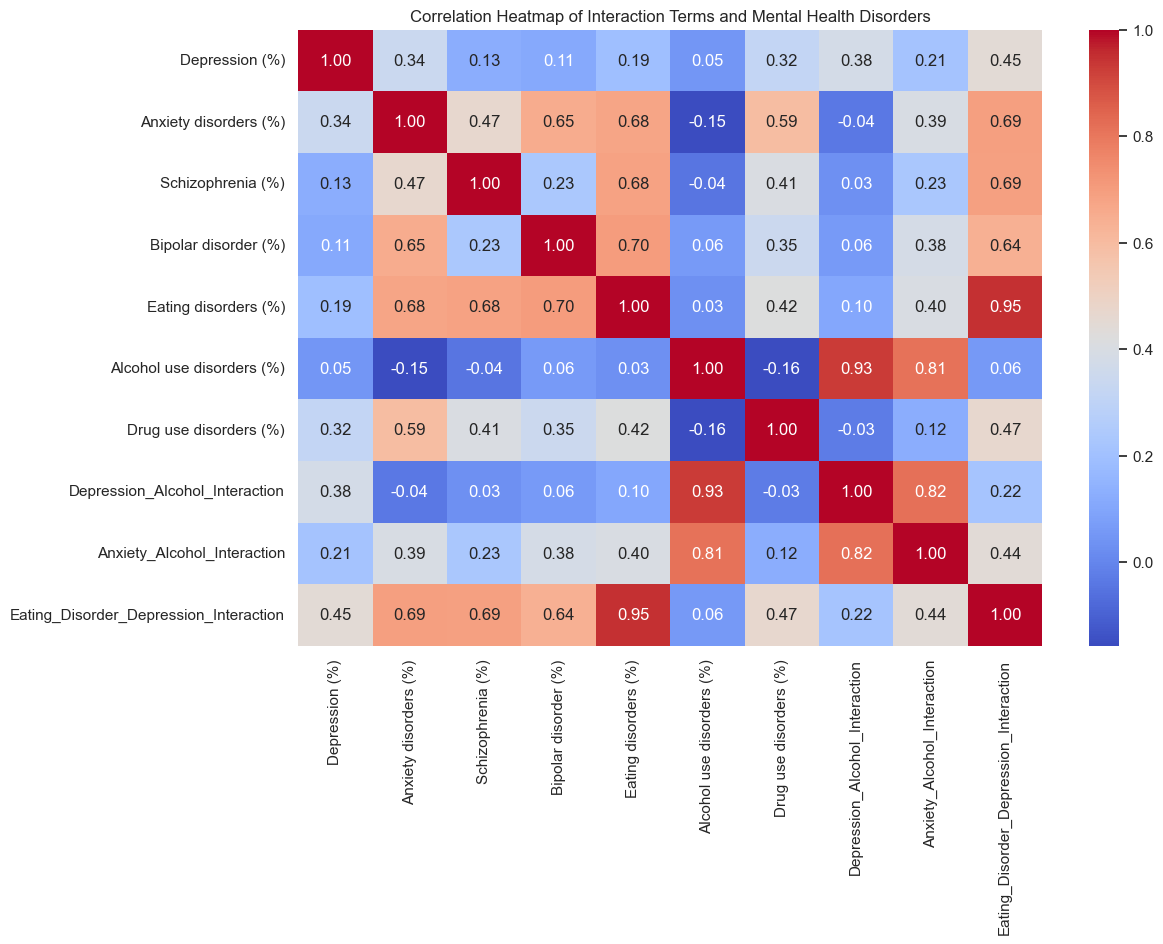

In [ ]:
# create interaction terms to visualize much more complex relationships
mental_health_df['Depression_Alcohol_Interaction'] = mental_health_df['Depression (%)'] * mental_health_df['Alcohol use disorders (%)']
mental_health_df['Anxiety_Alcohol_Interaction'] = mental_health_df['Anxiety disorders (%)'] * mental_health_df['Alcohol use disorders (%)']
mental_health_df['Eating_Disorder_Depression_Interaction'] = mental_health_df['Eating disorders (%)'] * mental_health_df['Depression (%)']


# Select all columns for correlation calculation, including the new interaction terms
interaction_correlation_matrix = mental_health_df[['Depression (%)', 'Anxiety disorders (%)', 'Schizophrenia (%)', 'Bipolar disorder (%)', 'Eating disorders (%)', 'Alcohol use disorders (%)', 'Drug use disorders (%)',
                                                   'Depression_Alcohol_Interaction', 'Anxiety_Alcohol_Interaction', 'Eating_Disorder_Depression_Interaction']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(interaction_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Interaction Terms and Mental Health Disorders')
plt.show()


#interaction terms show multiple complex relationships between anxiety, mental health disorders and alcohol use disorders
# anxiety , eating disorders have a very strong relationship with alcohol use disorders

**MODEL TRAINING**

80/20 Train/Test split

In [133]:
# Define features (X) and target (y)
# Drop non-numeric and target columns
X = mental_health_df.drop(columns=['Entity', 'Year', 'Anxiety disorders (%)', 'Code', 'index', 'Depression_Alcohol_Interaction','Anxiety_Alcohol_Interaction', 'Eating_Disorder_Depression_Interaction'])
y = mental_health_df['Anxiety disorders (%)']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (4390, 6) (4390,)
Testing set shape: (1098, 6) (1098,)


## Model Evaluation

Label encoder

Initiate Linear Regression Func

In [134]:
# Fit the linear regression model directly, since 'Code' is not in X_train/X_test
model = LinearRegression()
model.fit(X_train, y_train)

print("Model coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model coefficients: [ 3.56466965  2.78220719  1.20842944  0.65985575  0.28527542 -0.19885696]
Intercept: -0.29929849428517086


In [135]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)



Mean Squared Error: 0.40708005699813454
R-squared: 0.6786306586306867


In [136]:
#check coefficients
print("n\Feature Impact on Anxiety")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

n\Feature Impact on Anxiety
                     Feature  Coefficient
0          Schizophrenia (%)     3.564670
1       Bipolar disorder (%)     2.782207
2       Eating disorders (%)     1.208429
3     Drug use disorders (%)     0.659856
4             Depression (%)     0.285275
5  Alcohol use disorders (%)    -0.198857


In [137]:
# standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [138]:
# train the linear regression model on the scaled features
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [139]:
# Predict Anxiety on the test set
y_pred_scaled = lr_model.predict(X_test_scaled)

Root Mean Squared Error (Scaled): 0.6380282572097685
Root Mean Squared Error (Train Scaled): 0.6518734556299662
R-squared (Scaled): 0.6786306586306867


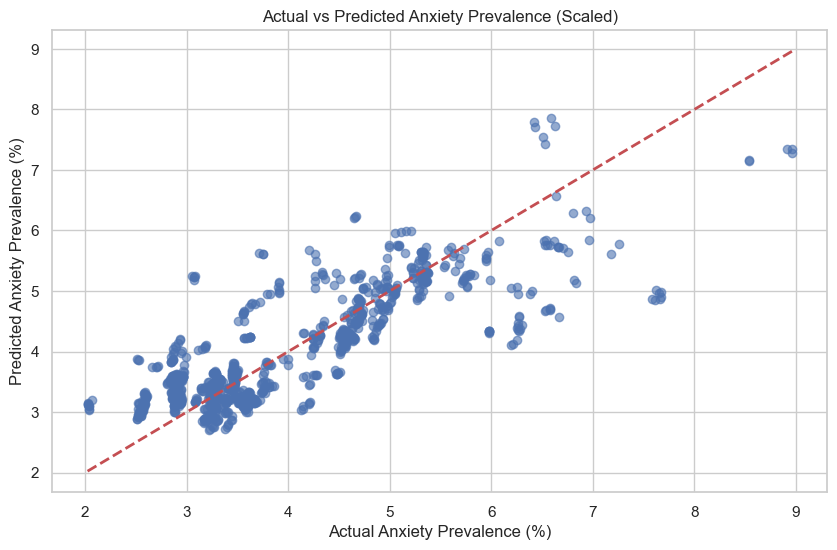

In [140]:
# Evaluate the model
mse_scaled = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (Scaled):", mse_scaled)
train_mse = np.sqrt(mean_squared_error(y_train, lr_model.predict(X_train_scaled)))
print("Root Mean Squared Error (Train Scaled):", train_mse)
print("R-squared (Scaled):", r2_score(y_test, y_pred_scaled))

# Visualize the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_scaled, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Anxiety Prevalence (%)')
plt.ylabel('Predicted Anxiety Prevalence (%)')
plt.title('Actual vs Predicted Anxiety Prevalence (Scaled)')
plt.grid(True)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22116\391050952.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


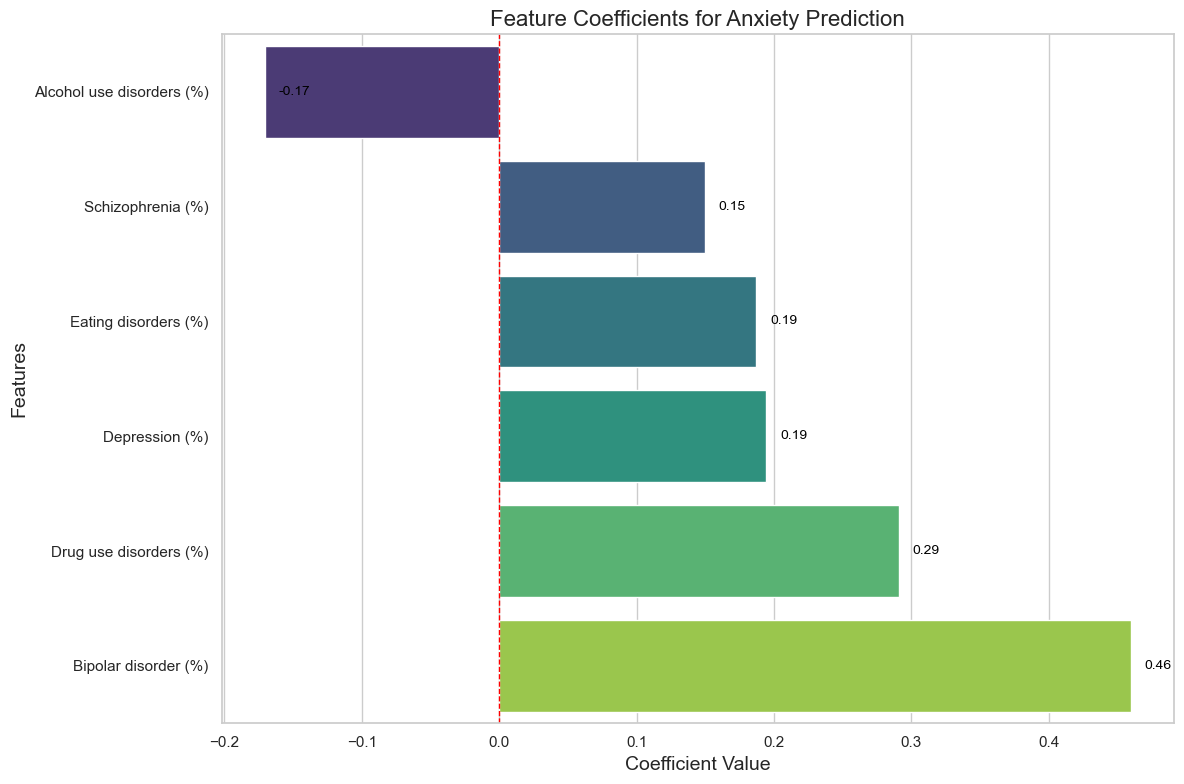

In [141]:
# create dataframe with coefficients
coefficient_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=coefficient_df, 
    palette='viridis'
)

# customize plot
plt.title('Feature Coefficients for Anxiety Prediction', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(0, color='red', linestyle='--', linewidth=1)

# add value annotations
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.01, p.get_y() + p.get_height() / 2, f'{width:.2f}',
             va='center', fontsize=10, color='black')
    
    # adjust layout
plt.tight_layout()

# Random Forest Model

In [142]:
from sklearn.ensemble import RandomForestRegressor


In [143]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


Predictions

In [144]:
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [145]:
# Predict Anxiety on the test set using Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
test_mse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
train_mse_rf = np.sqrt(mean_squared_error(y_train, rf_model.predict(X_train_scaled)))
r2_rf = r2_score(y_test, y_pred_rf)



In [146]:
print("Random Forest - Mean Squared Error:", test_mse_rf)
print("Random Forest - Train Mean Squared Error:", train_mse_rf)
print("Random Forest - R-squared:", r2_rf)

Random Forest - Mean Squared Error: 0.07531345493903327
Random Forest - Train Mean Squared Error: 0.023904081167689186
Random Forest - R-squared: 0.9955221477672891


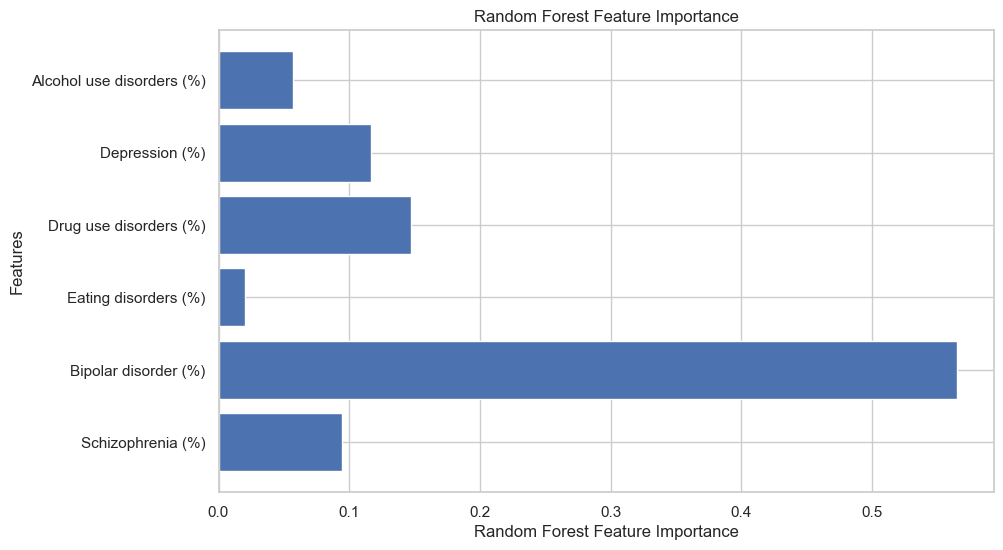

In [147]:
# get feature importances
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel('Random Forest Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance')
plt.show()

In [148]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=5, scoring='r2'
                        )

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


## Decision Tree Model

In [149]:
from sklearn.tree import DecisionTreeRegressor


In [150]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [151]:
y_pred_dt = dt_model.predict(X_test)

In [152]:
#evaluate
mse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree - Mean Squared Error:", mse_dt)
print("Decision Tree - R-squared:", r2_dt)

Decision Tree - Mean Squared Error: 0.42872232127660836
Decision Tree - R-squared: 0.8548968611819107


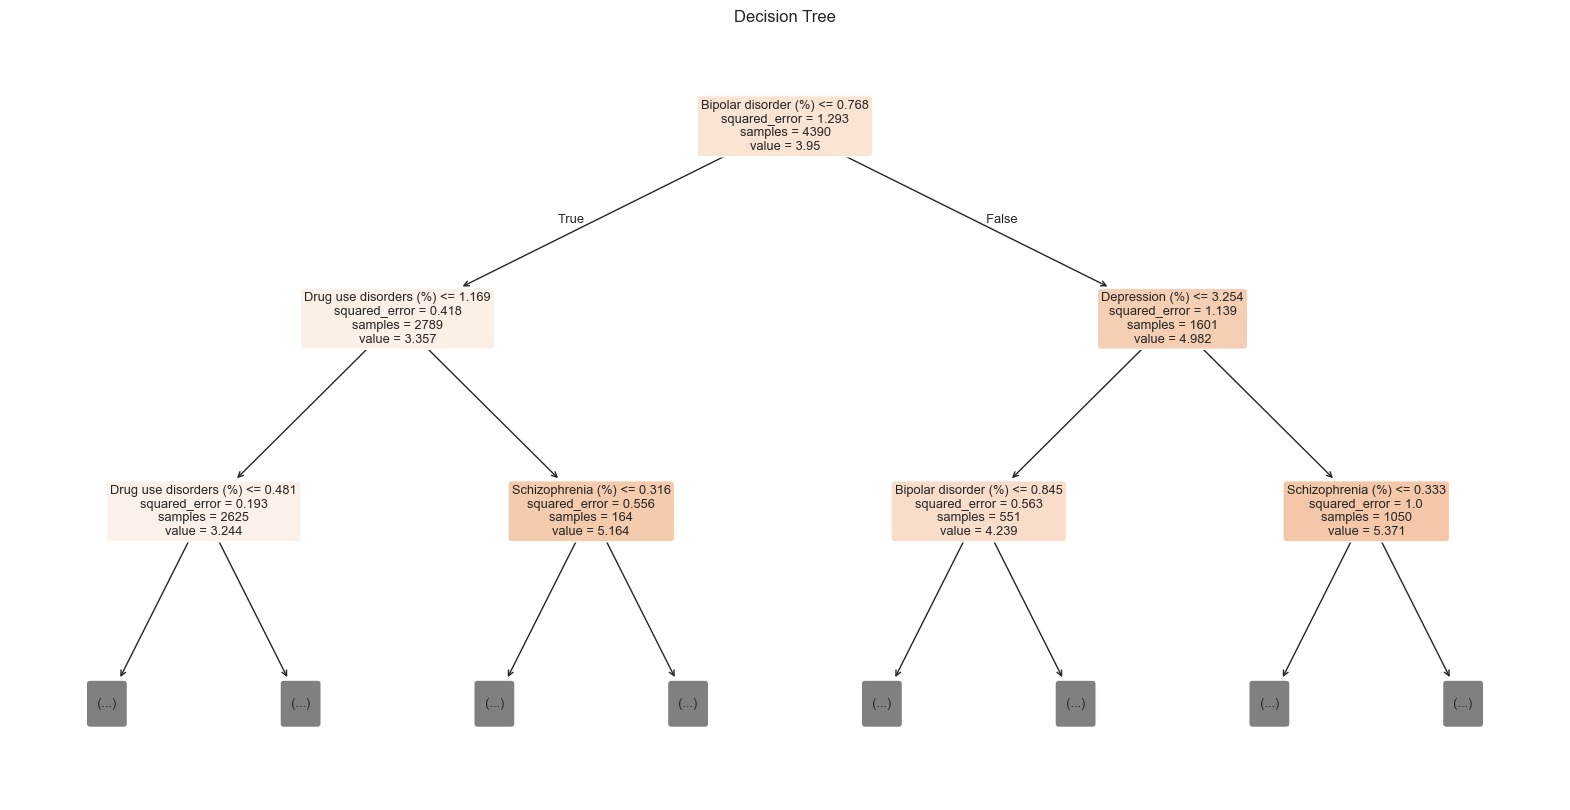

In [153]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, rounded=True, max_depth=2)
plt.title('Decision Tree')
plt.show()

## Model Comparison


In [154]:
#compare models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Decision Tree'],
    'Mean Squared Error': [mse, test_mse_rf, mse_dt],
    'R-squared': [r2, r2_rf, r2_dt]
}).sort_values(by='R-squared', ascending=False)

print(results)

               Model  Mean Squared Error  R-squared
1      Random Forest            0.075313   0.995522
2      Decision Tree            0.428722   0.854897
0  Linear Regression            0.407080   0.678631


Since the Random Forest Model has the lowest Mean Squared Error and the Highest R Squared Value, it is the most appropriate model

In [155]:
import joblib

In [156]:
joblib.dump(rf_model, 'anxiety_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

['feature_scaler.pkl']

In [157]:
# Fit LabelEncoder if not already fitted
le.fit(mental_health_df['Entity'])
label_mapping = {label: i for i, label in enumerate(le.classes_)}
joblib.dump(label_mapping, 'label_mapping.pkl')

['label_mapping.pkl']

In [158]:
print("Label encoder classes:", le.classes_)
print("Type:", type(le.classes_[0]))

Label encoder classes: ['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Cyprus'
 'Czech Republic' 'Democratic Republic of Congo' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Ethiopia' 'Fiji' 'Finland'
 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece'
 'Greenland' 'Grenada' 'Guam' 'Guatemala' 'Guinea' 'Guinea-Bissau'
 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia'
 'Iran' 'Iraq' 'Ireland' 'Israel' 'Ita

In [159]:
display(X)
display(y)

,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0.160560,0.697779,0.101855,1.677082,4.071831,0.672404
1,0.160312,0.697961,0.099313,1.684746,4.079531,0.671768
2,0.160135,0.698107,0.096692,1.694334,4.088358,0.670644
3,0.160037,0.698257,0.094336,1.705320,4.096190,0.669738
4,0.160022,0.698469,0.092439,1.716069,4.099582,0.669260
...,...,...,...,...,...,...
6463,0.155670,0.607993,0.117248,0.766280,3.128192,1.515641
6464,0.155993,0.608610,0.118073,0.768914,3.140290,1.515470
6465,0.156465,0.609363,0.119470,0.771802,3.155710,1.514751
6466,0.157111,0.610234,0.121456,0.772275,3.174134,1.513269


0       4.828830
1       4.829740
2       4.831108
3       4.830864
4       4.829423
          ...   
6463    3.090168
6464    3.093964
6465    3.098687
6466    3.104294
6467    3.110926
Name: Anxiety disorders (%), Length: 5488, dtype: float64